In [ ]:
import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[2])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import L1WaveletRecon


## My files
import save_data_helpers
import recon_functions
import recon_plot_helpers
from gating_functions import golden_angle_coords_3d
import sigpy.plot as pl

### Load data

In [2]:
idx, resp_trimmed, data_bins, spoke_bins, index_bins = save_data_helpers.load_gate_outputs_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl')
print(f'data_bins[0].shape = {data_bins[0].shape}')
print(f'spoke_bins[0].shape = {spoke_bins[0].shape}')

ksp_gate0 = data_bins[0]
coords_gate0 = spoke_bins[0]
ncoils, npts, nsamples = data_bins[0].shape
img_shape = (58, nsamples, nsamples)
print(f'img_shape = {img_shape}')

espirit_mps_gate0 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject2_mid0082/espirit_mps_full_res_ksp_512_ungated.pkl')
print(f'espirit_mps_gate0.shape = {espirit_mps_gate0.shape}')

dcf_ksp_5gates = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/pkl_files_512/dcf_ksp_dense_512_5gates.pkl')
dcf_ksp_gate0 = dcf_ksp_5gates[0]
print(f'dcf_ksp_gate0.shape = {dcf_ksp_gate0.shape}')

ksp_gate0_with_dcf = ksp_gate0 * dcf_ksp_gate0[None,...]
print(f'ksp_gate0_with_dcf.shape = {ksp_gate0_with_dcf.shape}')

Loaded /home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl
  idx shape: (113116,)
  signal_trimmed shape: (113116,)
  data_bins: 5 elements
  spoke_bins: 5 elements
  index_bins: 5 elements
data_bins[0].shape = (15, 22623, 512)
spoke_bins[0].shape = (22623, 512, 3)
img_shape = (58, 512, 512)
espirit_mps_gate0.shape = (15, 58, 512, 512)
dcf_ksp_gate0.shape = (22623, 512)
ksp_gate0_with_dcf.shape = (15, 22623, 512)


In [3]:
# ksp_512 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/ksp_from_mdb_512_samples.pkl')
# ksp_512 = np.transpose(ksp_512, (2, 0, 1, 3))
# print(f'ksp_512.shape = {ksp_512.shape}')

# ## Use first 400 spokes to speed up computation
# ksp_data = ksp_512[:, :, :400, :]
# print(f'ksp_data.shape = {ksp_data.shape}')

# ncoils, nslices, nspokes, nsamples = ksp_data.shape
# img_shape = (nslices, nsamples, nsamples)

# ## Golden angle coords
# coords = golden_angle_coords_3d(img_shape=img_shape, num_spokes=nspokes, num_points=nsamples)
# print(f'coords.shape = {coords.shape}')

# espirit_mps = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject2_mid0082/espirit_mps_full_res_ksp_512_ungated.pkl')
# print(f'espirit_mps.shape = {espirit_mps.shape}')

# dcf_ksp = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/pkl_files_512/dcf_ksp_less_spokes_512.pkl')
# print(f'dcf_ksp.shape = {dcf_ksp.shape}')

# ksp_with_dcf = ksp_data * dcf_ksp[None,:,:, :]
# print(f'ksp_with_dcf.shape = {ksp_with_dcf.shape}')

In [4]:
coils_select = [1, 8, 9, 10, 13]
ksp_coil_select = [ksp_gate0_with_dcf[i] for i in coils_select]
ksp_coil_select = np.stack(ksp_coil_select, axis=0)
mps_coil_select = [espirit_mps_gate0[i] for i in coils_select]
mps_coil_select = np.stack(mps_coil_select, axis=0)

In [5]:
print(ksp_coil_select.shape)

(5, 22623, 512)


In [6]:
device = 1
num_coils = 6
ksp = ksp_coil_select.astype(np.complex64)
mps = mps_coil_select

ncoils, nz, ny, nx = mps.shape
print(f'ncoils = {ncoils}')

ksp = sp.to_device(ksp, device)
mps = sp.to_device(mps, device)
coords = sp.to_device(coords_gate0, device)

img_shape = mps.shape[1:]

with sp.Device(1):
    # All operators will automatically work on the device of the input arrays
    S = sp.linop.Multiply(img_shape, mps)
    F = sp.linop.NUFFT(mps.shape, coord=coords)
    W = sp.linop.Wavelet(img_shape, wave_name='db4', level=4)
    A = F * S * W.H

    ## Get k-space for gradient function
    ## Apply NUFFT and regularize from [0,1]
    nufft_res = F.H * ksp
    nufft_res_norm = np.zeros_like(nufft_res)
    for coil in range(nufft_res_norm.shape[0]):
        img = np.abs(nufft_res[coil])
        nufft_res_norm[coil] = (img - np.min(img)) / (np.max(img) - np.min(img))


    ## Apply Sense and regularize from [0,1]
    nufft_sense = S.H * nufft_res_norm
    img = np.abs(nufft_sense)
    nufft_sense_norm =  (img - np.min(img)) / (np.max(img) - np.min(img))

    ## Apply Wavelet, get coeffs, turn back into ksp
    wav_norm = W * nufft_sense_norm
    ksp_norm = A * wav_norm

ncoils = 5


/home/lilianae/mambaforge/envs/jointrecon_env_backup_new/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(


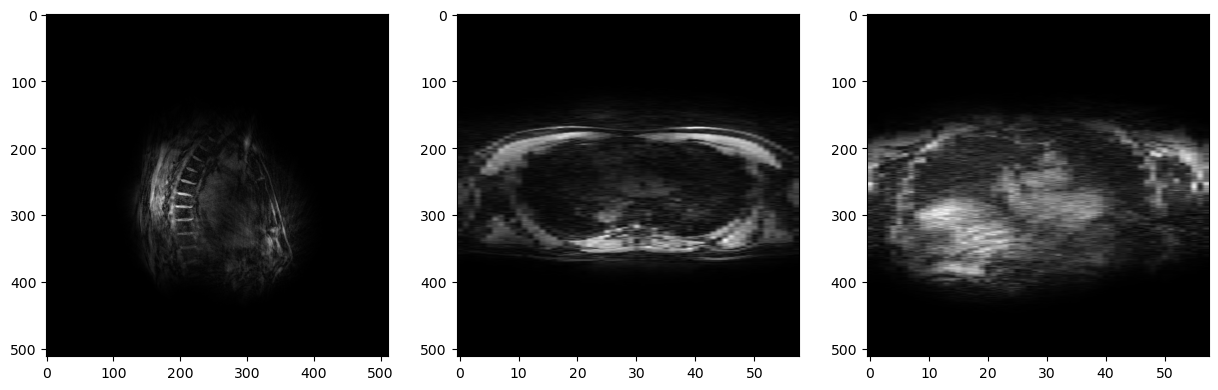

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [7]:
recon_plot_helpers.plot_recons_all_axes(cp.asnumpy(nufft_sense_norm))

L1WaveletRecon, Iteration=30

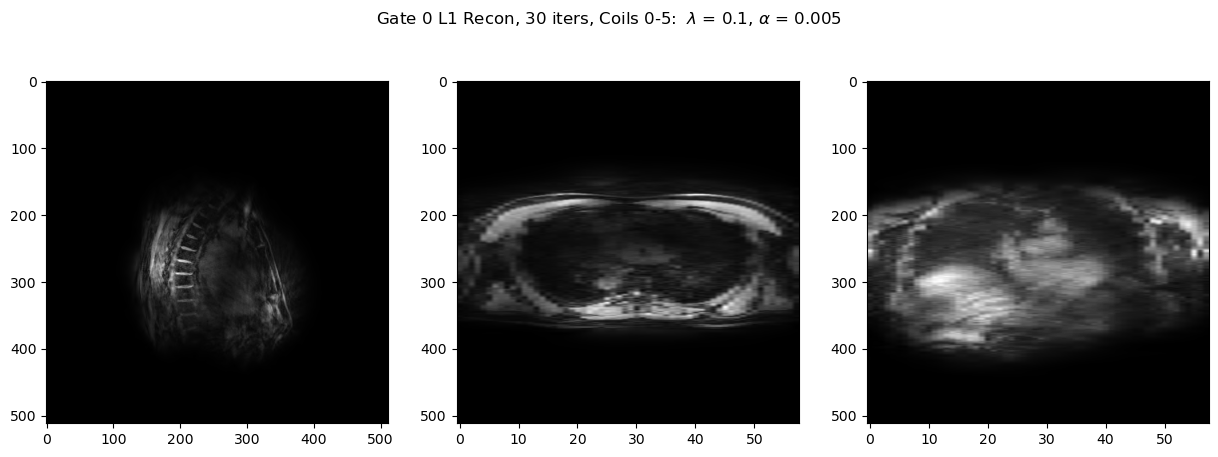

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [8]:
lamda = 0.1
alpha = 0.005
max_iter = 30

# lams = [1e-4, ]

proxg = sp.prox.L1Reg(A.ishape, lamda=lamda)

with cp.cuda.Device(1):
    wav = wav_norm.astype(np.complex64)


def gradf(x):
    return A.H * (A * x - ksp_norm)

alg = sp.alg.GradientMethod(gradf, wav, alpha, proxg=proxg, 
                            max_iter=max_iter)

while not alg.done():
    alg.update()
    print('\rL1WaveletRecon, Iteration={}'.format(alg.iter), end='')

final_img = (W.H(alg.x))
final_img = cp.asnumpy(final_img)
recon_plot_helpers.plot_recons_all_axes(final_img, title=rf"Gate 0 L1 Recon, {alg.iter} iters, Coils 0-5:  $\lambda$ = {lamda}, $\alpha$ = {alpha}")

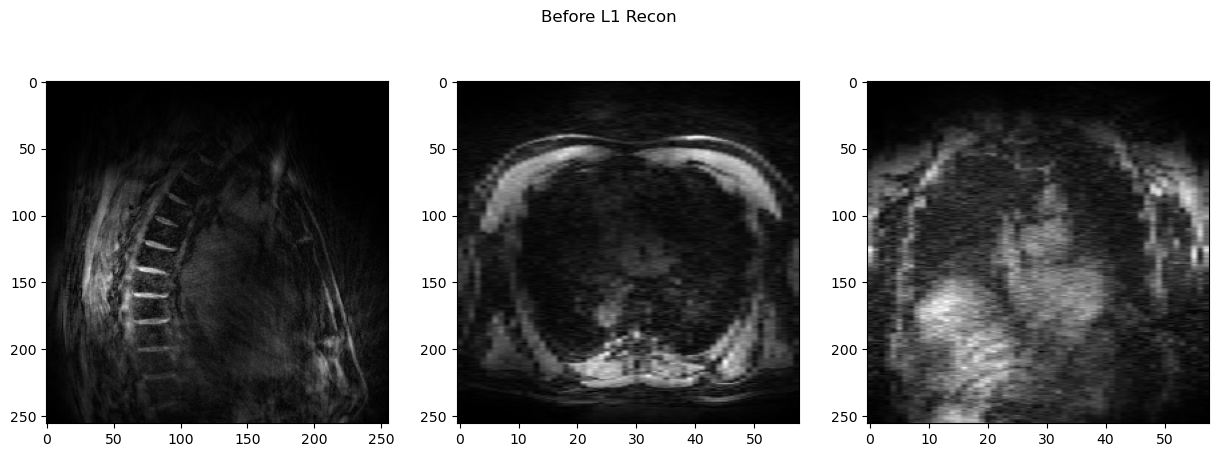

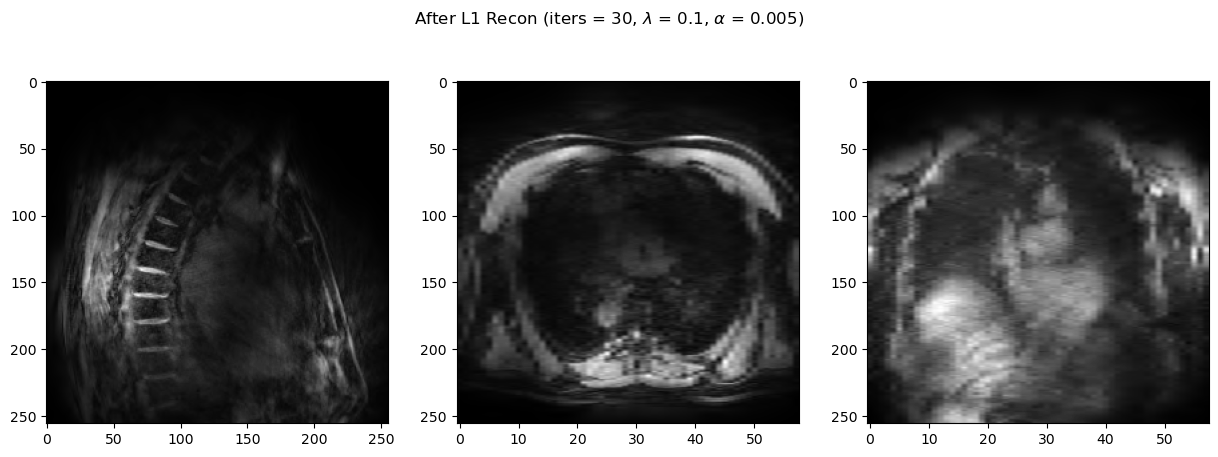

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [9]:
# Center crop from 512x512 to 256x256
# Calculate the starting indices for the crop
start_h = (512 - 256) // 2  # 128
start_w = (512 - 256) // 2  # 128

# Crop along the last two dimensions
og_cropped = nufft_sense_norm[:, start_h:start_h+256, start_w:start_w+256]
recon_cropped = final_img[:, start_h:start_h+256, start_w:start_w+256]


recon_plot_helpers.plot_recons_all_axes(cp.asnumpy(og_cropped), title=f'Before L1 Recon')
recon_plot_helpers.plot_recons_all_axes(recon_cropped, title=rf'After L1 Recon (iters = {alg.iter}, $\lambda$ = {lamda}, $\alpha$ = {alpha})')

In [10]:
# save_data_helpers.write_pickle(final_img, f'final_img_gate0{alg.iter}iters_l1_lam{lamda}_alpha{alpha}_coils0{num_coils}')